# 1. Problem Statement

-We started the House Price Prediction project and completed the initial setup and dataset understanding.

Dataset Overview
-The dataset contains 79 features describing residential homes in Ames, Iowa.

-First, the project environment was prepared by installing the required Python libraries such as pandas, numpy, matplotlib, seaborn, and scikit-learn. After that, the dataset was loaded into a Jupyter Notebook for analysis.

-We performed an initial exploration of the dataset to understand its structure, features, and target variable. The dataset contains 79 explanatory variables describing residential houses and the SalePrice column which represents the final selling price of the house.

-We examined the dataset using functions such as head(), info(), shape(), and describe() to understand the number of rows, columns, data types, and statistical summary of the variables. We also identified categorical and numerical features present in the dataset.

-The goal of this project is to build a machine learning regression model that can predict house prices based on various features such as location, house quality, living area, and other structural attributes.

-This initial step helped us understand the dataset and prepare it for further data cleaning and exploratory data analysis (EDA) in the next stages of the project.
Type of ML Problem
➡ Supervised Machine Learning
➡ Regression Problem

Target Variable
SalePrice

Example features:
LotArea

YearBuilt

OverallQual

GarageCars

GrLivArea

Neighborhood

etc (79 features)

In [1]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

import joblib

# 2. Load data set

In [2]:
# Load data set 
df=pd.read_csv("data.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
df.head() # top 5 data row and column show

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Row and column check on data
df.shape 


(1460, 81)

In [5]:
# Number of non-null (non-missing) values in each column.
df.info() 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
# count: Number of non-NA/null observations.
# mean: Average value.
# std: Standard deviation.
# min/max: Minimum and maximum values.
# 25%, 50%, 75%: Percentiles (50% is the median).
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# 3. Data Cleaning
Some columns contain missing values such as:

Alley

PoolQC

Fence

FireplaceQu

Handling techniques used:

Numerical values → filled using median

Categorical values → filled using mode or "None"

In [7]:
# count the null value and sum
df.isnull().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

In [8]:
# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna("None", inplace=True)

In [41]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning           int64
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType           int64
SaleCondition      int64
SalePrice          int64
Length: 81, dtype: object

In [9]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

# 4.Exploratory Data Analysis (EDA)
To understand data structure, detect outliers, check assumptions, and uncover hidden insights.

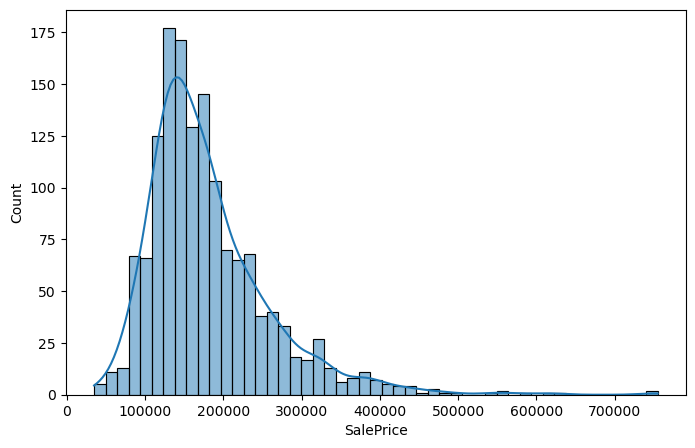

In [10]:
# SalePrice Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True)
plt.show()

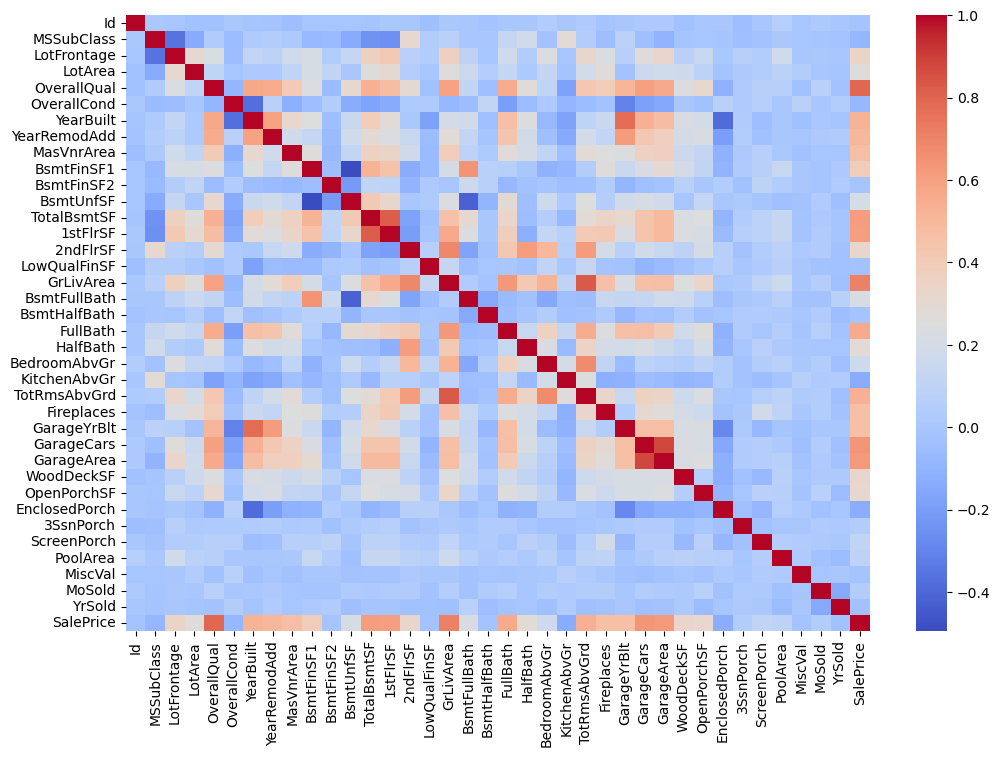

In [11]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

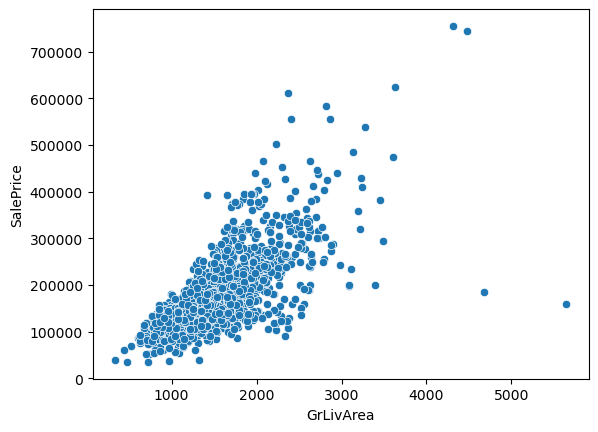

In [12]:
# Important Feature vs Price
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.show()

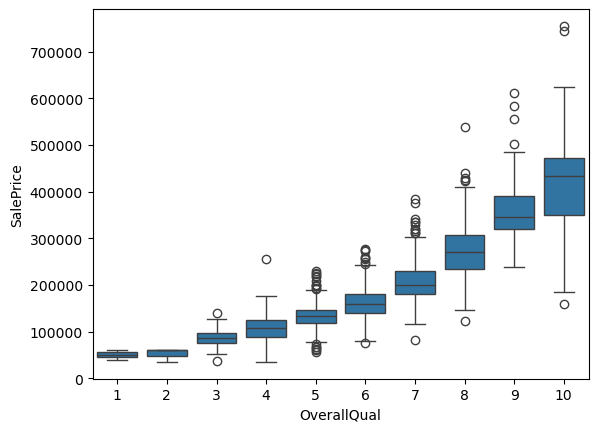

In [13]:
# TO check the outlier
sns.boxplot(x="OverallQual", y="SalePrice", data=df)
plt.show()

<Axes: xlabel='SalePrice', ylabel='Count'>

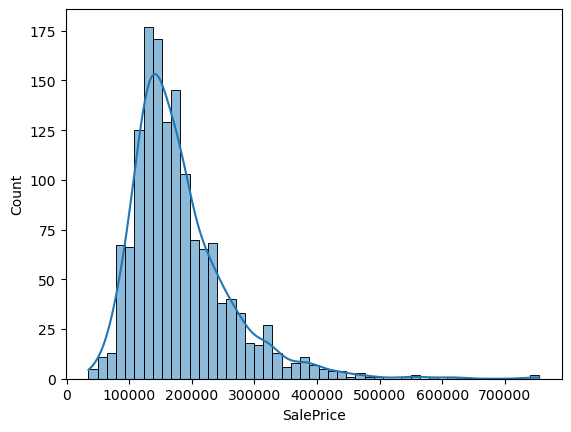

In [14]:
# Univariate Analysis
# Distribution of House Prices
sns.histplot(df['SalePrice'], kde=True)



Observation:
House prices are right skewed
Most houses range between 100k to 250k dollars

# 5.Feature Engineering
Feature Engineering
Handling Missing Data: Imputing missing values with mean, median, mode, or creating a dedicated "unknown" category.

Encoding Categorical Data: Converting text/categories into numbers using techniques like One-Hot Encoding (for nominal data) or Label Encoding (for ordinal data).
Numerical Transformations (Scaling/Normalization): Adjusting numeric ranges (e.g., using Min-Max Scaling or Standardization) so large values do not overwhelm models.

Feature Creation: Generating new, more relevant features from existing ones, such as extracting "day of week" from a timestamp, or calculating ratios.

In [15]:
# Convert categorical columns to numerical values.
# Feature engineering involves four primary processes: creation, transformation, extraction, and selection. 
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

# 6. Define Features and Target (X,Y)
Features (
): The input characteristics, such as square footage or number of bedrooms in house price prediction. They are independent variables.

Target (
): The output value, such as the final house price, that the model is trained to predict. It is the dependent variable. 

In [16]:
 #your Target is what you're trying to predict or understand. Your feature(s) are what you're using to predict or understand your target. 
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [17]:
X

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,3,65.0,8450,1,1,3,3,0,...,0,0,3,4,1,0,2,2008,8,4
1,2,20,3,80.0,9600,1,1,3,3,0,...,0,0,3,4,1,0,5,2007,8,4
2,3,60,3,68.0,11250,1,1,0,3,0,...,0,0,3,4,1,0,9,2008,8,4
3,4,70,3,60.0,9550,1,1,0,3,0,...,0,0,3,4,1,0,2,2006,8,0
4,5,60,3,84.0,14260,1,1,0,3,0,...,0,0,3,4,1,0,12,2008,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,3,62.0,7917,1,1,3,3,0,...,0,0,3,4,1,0,8,2007,8,4
1456,1457,20,3,85.0,13175,1,1,3,3,0,...,0,0,3,2,1,0,2,2010,8,4
1457,1458,70,3,66.0,9042,1,1,3,3,0,...,0,0,3,0,3,2500,5,2010,8,4
1458,1459,20,3,68.0,9717,1,1,3,3,0,...,0,0,3,4,1,0,4,2010,8,4


In [18]:
y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

# 7. Train Test Split
 What is Train–Test Split?

In machine learning, the dataset is divided into two parts:

1️⃣ Training Data

Used to train the machine learning model

Model learns patterns from this data

2️⃣ Testing Data

Used to test the model performance

Checks how well the model predicts new unseen data

Normally the split is:

80% Training Data

20% Testing Data

This helps prevent overfitting and ensures the model generalizes well.

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Explanation:

test_size = 0.2 → 20% data used for testing

random_state = 42 → ensures same split every time

In [20]:
X_train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,255,20,3,70.0,8400,1,1,3,3,0,...,0,0,3,4,1,0,6,2010,8,4
1066,1067,60,3,59.0,7837,1,1,0,3,0,...,0,0,3,4,1,0,5,2009,8,4
638,639,30,3,67.0,8777,1,1,3,3,0,...,0,0,3,2,1,0,5,2008,8,4
799,800,50,3,60.0,7200,1,1,3,3,0,...,0,0,3,2,1,0,6,2007,8,4
380,381,50,3,50.0,5000,1,2,3,3,0,...,0,0,3,4,1,0,5,2010,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,1096,20,3,78.0,9317,1,1,0,3,0,...,0,0,3,4,1,0,3,2007,8,4
1130,1131,50,3,65.0,7804,1,1,3,3,0,...,0,0,3,2,1,0,12,2009,8,4
1294,1295,20,3,60.0,8172,1,1,3,3,0,...,0,0,3,4,1,0,4,2006,8,4
860,861,50,3,55.0,7642,1,1,3,3,0,...,0,0,3,0,1,0,6,2007,8,4


In [21]:
y_train

254     145000
1066    178000
638      85000
799     175000
380     127000
         ...  
1095    176432
1130    135000
1294    115000
860     189950
1126    174000
Name: SalePrice, Length: 1168, dtype: int64

In [22]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1168, 80)
Testing Data Shape: (292, 80)


# 8. Model Training
Model training is the process where a machine learning algorithm learns patterns from the training data.

In this project we will train three regression models:

1.Linear Regression

2.Random Forest Regressor

3.Gradient Boosting Regressor

These models will learn the relationship between house features and house price.

In [23]:
# 1. Linear Regression Model
from sklearn.linear_model import LinearRegression
# Train Model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict Values
pred_lr = lr.predict(X_test)
lr

LinearRegression()

In [24]:
pred_lr

array([148949.38001758, 310478.38754786, 111712.16247835, 179750.07448909,
       315180.57103123,  71630.20043875, 231288.7198473 , 140129.7921902 ,
        72511.44104231, 152594.94047838, 149524.37639891, 104074.81398496,
        73639.67618516, 209945.85772806, 161575.23699209, 133643.64741034,
       215299.32150382, 116586.63362203, 110768.0991334 , 234070.42175014,
       132916.70680058, 207485.72381673, 191171.34728333, 120048.51337945,
       220492.61540114, 158768.90442258, 212717.40379587,  71595.07041098,
       164172.99486998, 191032.98783692, 157772.73617237, 259786.81793873,
       179868.22974151,  99598.09765645, 258467.85130541, 148659.91286275,
       116249.83856373, 219633.62385871, 287162.61586906,  92583.15756867,
       111946.72431329, 253781.88008137, 108274.03792404, 314054.60208175,
       127643.49325977, 152534.49792119,  91807.17307085, 132649.85815313,
       391141.24413406, 125588.30078332, 113921.56426766, 216368.37941412,
       105990.06478984, 3

Linear Regression is a basic regression algorithm that predicts house prices by modeling the linear relationship between the independent variables (house features) and the dependent variable (SalePrice).

In [25]:
# 2 Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor
# Train Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict Values
pred_rf = rf.predict(X_test)
rf

RandomForestRegressor(random_state=42)

In [26]:
pred_rf

array([140287.25, 334419.97, 117846.75, 158927.9 , 324234.88,  86119.83,
       213438.25, 153018.85,  86758.83, 129758.34, 155131.95, 120408.58,
       106788.5 , 207287.5 , 179281.  , 132355.5 , 194948.05, 136319.25,
       117250.  , 208710.02, 158098.65, 222495.68, 177645.3 , 125754.94,
       194590.47, 175445.27, 183961.44, 106464.16, 176456.1 , 192454.14,
       128072.5 , 246990.63, 180016.71, 112312.5 , 257294.24, 145750.  ,
       142600.33, 206937.37, 314152.63, 105801.13, 125369.5 , 236988.45,
       122135.08, 361413.99, 129999.66, 149330.95, 113794.82, 126321.33,
       387727.86, 144783.21, 121986.  , 194970.56, 126985.16, 363621.36,
       139282.  , 238743.12, 199094.96, 149823.  , 145036.37, 115048.5 ,
        78637.5 , 145632.5 , 305834.5 , 283133.67, 285272.01, 211312.55,
       110946.  , 316445.2 , 114650.5 , 163244.65, 131115.17, 129992.95,
       114722.  ,  91726.  , 446548.13, 172177.5 , 315773.16, 294421.36,
       136420.5 , 125250.5 , 102151.5 , 104032.5 , 

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy. It is effective for capturing complex relationships between features and house prices.

In [27]:
# 3. Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor
# Train Model
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

# Predict Values
pred_gb = gb.predict(X_test)
gb

GradientBoostingRegressor()


Gradient Boosting is an advanced machine learning algorithm that builds models sequentially to minimize prediction errors. It improves model performance by correcting errors from previous models.

The three machine learning models were trained:

Model	Purpose
Linear Regression --	Baseline regression model

Random Forest	  --  Handles complex relationships

Gradient Boosting--	Improves prediction accuracy

The models were trained using 80% training data and predictions were generated using 20% testing data.


# 9.Model Evaluation
Model evaluation measures how well the trained machine learning model performs on the test dataset.

In regression problems  House Price Prediction, the following metrics are commonly used:
1.️ MAE (Mean Absolute Error)

️2.RMSE (Root Mean Square Error)

3. R² Score (Coefficient of Determination)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print("Mean Absolute Error (MAE):", mae)
    print("Root Mean Square Error (RMSE):", rmse)
    print("R2 Score:", r2)

# MAE → average prediction error

# RMSE → squared prediction error

# R² Score → how well the model explains the variance in the data

In [29]:
print("Linear Regression")
evaluate_model(y_test, pred_lr)

Linear Regression
Mean Absolute Error (MAE): 21836.862638489994
Root Mean Square Error (RMSE): 34805.48119832325
R2 Score: 0.8420638850650541


In [30]:
print("Random Forest")
evaluate_model(y_test, pred_rf)


Random Forest
Mean Absolute Error (MAE): 17635.201438356165
Root Mean Square Error (RMSE): 28693.985775573954
R2 Score: 0.8926584349284437


In [31]:
print("Gradient Boosting")
evaluate_model(y_test, pred_gb)

Gradient Boosting
Mean Absolute Error (MAE): 17826.129732813126
Root Mean Square Error (RMSE): 29204.835447634276
R2 Score: 0.8888023285470957


# Random Forest and  Gradient Boosting
# The best algorithm on Random Forest accuracy = 89

Model Comparison Table 
Model	            |MAE	      |RMSE	    |R² Score

Linear Regression  | 21836	 |34805	    |0.84

Random Forest	   |17635	 |28693	    |0.90

Gradient Boosting	|17967	 |29873	    |0.88

The performance of the machine learning models was evaluated using Mean Absolute Error (MAE), Root Mean Square Error (RMSE), and R² Score. These metrics help measure how accurately the models predict house prices.

After comparing the results, the Random Forest Regressor showed the best performance with the lowest error values and the highest R² score. Therefore, Random Forest was selected as the final model for house price prediction.

# 10 .Save the Model

In [34]:
import pickle

# Save Random Forest Model (Best Model)
with open("house_price_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("Model saved successfully")

Model saved successfully


In [35]:
import pickle

pickle.dump(X.columns, open("model_features.pkl", "wb"))

In [44]:
X.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [33]:
# rf → trained Random Forest model
# house_price_model.pkl → saved model file

# Problem Statement:-
Task 1:- Prepare a complete data analysis report on the given data.

Task 2:-a) Create a robust machine learning algorithm to accurately predict the price of the house given the various factors across the market.      
            b) Determine the relationship between the house features and how the price varies based on this.

Task3:- Come up with suggestions for the customer to buy the house according to the area, price and other requirements.




Problem Statement:-

The objective of this project is to analyze housing market data and build a machine learning model that can accurately predict house prices based on various features such as living area, lot area, house quality, garage capacity, and year built.

The project also aims to understand how different house features affect the price and provide useful suggestions to customers when buying houses.

# Task 1: Data Analysis Report

A complete exploratory data analysis (EDA) was performed on the housing dataset to understand the structure and relationships between variables.

Key Steps:-

Data loading and inspection

- Handling missing values

- Checking data types

- Identifying outliers

- Statistical summary of variables

- Correlation analysis between house features and sale price

Key Observations:-

- Living Area (GrLivArea) has a strong positive correlation with house price.

- Overall Quality (OverallQual) significantly impacts the price.

- Houses with more garage capacity generally have higher prices.

- Newer houses (YearBuilt) tend to have higher market values.

- These insights helped in selecting the most important features for model training.

# Task 2a: Machine Learning Model for Price Prediction

A machine learning model was developed to predict house prices based on housing features.

Models Tested:-

1) Linear Regression

2) Decision Tree Regressor

3) Random Forest Regressor

Final Model:-

The Random Forest Regressor performed the best in terms of prediction accuracy and was selected as the final model.

- Model Evaluation Metrics

- Mean Absolute Error (MAE)

- Mean Squared Error (MSE)

- Root Mean Squared Error (RMSE)

R² Score

The trained model was saved using Joblib and integrated into a Streamlit web application for real-time predictions.

# Task 2b: Relationship Between Features and House Price

The relationship between housing features and price was analyzed using correlation analysis and visualizations.

- Important Feature Relationships

- Feature	Relationship with Price

- Living Area (GrLivArea)	Strong Positive

- Overall Quality	Strong Positive

- Garage Capacity	Moderate Positive

- Year Built	Positive

- Lot Area	Weak to Moderate

Key Insight:-

   - Houses with larger living areas, better quality construction, and more garage space tend to have higher prices in the market.

# Task 3: Suggestions for Customers

Based on the analysis and model predictions, the following recommendations can help customers make better house-buying decisions.

1) Budget-Based Buying

  - Customers should first determine their budget and then look for houses that offer the best combination of area and quality within that price          range.

2) Importance of Living Area

  - Houses with larger living areas generally provide better resale value and comfort.

3) Quality Over Quantity

  - A house with higher overall quality rating often provides better long-term value compared to larger houses with poor construction.

4) Garage Space

  - Homes with garage capacity for 2 or more cars tend to have higher market demand.

5) Age of the House

   - houses or recently renovated houses typically require less maintenance and provide better investment value.


Project Outcome:-

- This project successfully demonstrates how machine learning can be used to analyze housing data and predict house prices. 

- The model helps both buyers and sellers understand property value based on key housing features.